# Part C Dissertation - Modelling Networks with Complex Weights
## Cyclic SBM Generator
#### _(Candidate 1074092)_

In this notebook, we introduce the cyclic SBM. In the first section, we provide visualisations that are used in the main body of the dissertation, and then we run trials that show how noise reduces the efficacy of the spectral gap criterion.

In the dissertation, we proposed an a priori method for selecting the number of clusters assigned to our spectral clustering algorithm. This criterion was to choose $r$ that maximises the spectral gap $\lambda_2 - \lambda_1$. This was motivated firstly by the fact that $r$ naturally selects the number of clusters that the magnetic Laplacian algorithm will look for, and also by the perturbation theory esetimates in Chapter 3 which prove that $\lambda_2$ well separated if and only if $\lambda_2$ large does not hold due to potential large perturbations in $\lambda_1$.

This criterion is effectively an analogue of the often used eigengap heuristic (detailed in von Luxburg, [22]) for the magnetic Laplacian. It can also be described as an analogue of the Fiedler value $\lambda_2$, because with the standard graph Laplacian we have that $\lambda_1 \equiv 0$.

For a detailed explanation of how the cyclic SBM is set up, find Section 4.2 of the dissertation.

Below are visualisations for the cyclic SBM.

In [1]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import scipy.special as sp
import pickle
import os
rng = np.random.default_rng(seed=None)

In [2]:
n = 10
p = 0.2
A = rng.binomial(1, p, size=(n, n))
print(A)

[[0 0 0 0 0 0 0 1 0 1]
 [1 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 1 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 1 1 0 0]]


In [3]:
def sbmCycleGen(clusters, clust_size, p_in, p_out):
    n = clusters * clust_size
    #generates a full matrix of p_out, we will overwrite this later
    A = rng.binomial(1, p_out, size=(n, n))
    #makes diagonal 0 (removes self edges)
    np.fill_diagonal(A, 0)

    #adds the block matrices showing "in" connections from cluster i to cluster i+1
    #we hard code in the bottom corner block
    for i in range(0, clusters-1):
        #creates in blocks
        A_in_block = rng.binomial(1, p_in, size=(clust_size, clust_size))
        #places in blocks above the diagonal
        A[((i)*clust_size):((i+1)*clust_size), ((i+1)*clust_size):((i+2)*clust_size)] = A_in_block
    A_in_block = rng.binomial(1, p_in, size=(clust_size, clust_size))
    A[(n-clust_size):n, 0:clust_size] = A_in_block
    return A

In [4]:
def mLapN(M, theta):
    M = M.toarray()
    n = np.shape(M)[0]
    #defines unweighted symmetric matrix
    W_s = (M + M.T) / 2

    #directional info matrix
    A = M
    A[(M > 0) & (M.T == 0)] = 1
    A[(M == 0) & (M.T > 0)] = -1
        
    #T matrix
    T = np.exp(1j * theta * A)
    #L matrix
    L = -W_s * T
    np.fill_diagonal(L, np.sum(W_s, axis=1))

    #Normalisation step, sets L_N = D^(-1/2) * L * D^(-1/2)
    D = np.sum(W_s, axis=1)
    normD = 1 / np.sqrt(D)
    L_N = (normD[:, None] * L) * normD[None, :]
    
    return L_N

def eig_rValuesN(A, rValues):
    sims = len(rValues)
    n = np.shape(A)[0]
    eigArray = np.empty((sims, n + 1), dtype=float)
    #note that we essentially set q = theta/2π, so for varying r as before we have r = 1/q
    thetaValues = (2*np.pi)/np.array(rValues)
    
    for i in range (0, sims):
        L_N = mLapN(A, thetaValues[i])
        eigs = np.linalg.eigvalsh(L_N)
        eigArray[i, 0] = rValues[i]
        for j in range(0, n):
            eigArray[i, j + 1] = eigs[j]
    return eigArray

def eigValues_plot(eigArray, n, idp, graphname):
    plt.figure(figsize=(6, 4))
    for i in range(0, n):
        plt.plot(eigArray[:, 0], eigArray[:, i + 1], label=rf"$\lambda_{{{i + 1}}}$")
    plt.xlabel(f"{idp}")
    plt.ylabel("λ")
    plt.title(f"λ (for varying {idp}) of {graphname}")
    plt.grid(True)
    plt.legend()
    plt.show()

def eigV_rplot(G, graphname):
    A = nx.adjacency_matrix(G)
    rValues = [n for n in range (1, 101)] 
    n = np.shape(G)[0]
    eigArrayN = eig_rValuesN(A, rValues)
    eigValues_plot(eigArrayN, n, "r", graphname)

def eigVsel_plot(eigArray, n, idp, graphname, eigInterest):
    plt.figure(figsize=(6, 4))
    for i in eigInterest:
        plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$")
    plt.xlabel(f"{idp}")
    plt.ylabel("λ")
    plt.title(f"λ (for varying {idp}) of {graphname}")
    plt.grid(True)
    plt.legend()
    plt.show()

def eigVsel_rplot(G, graphname, rValues, eigInterest):
    A = nx.adjacency_matrix(G)
    n = np.shape(G)[0]
    eigArrayN = eig_rValuesN(A, rValues)
    eigVsel_plot(eigArrayN, n, "r", graphname, eigInterest)

In [5]:
clusters = 5
clust_size = 5
p_in = 1
p_out = 0.1
A = sbmCycleGen(clusters, clust_size, p_in, p_out)
print(A)

[[0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
 [0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 

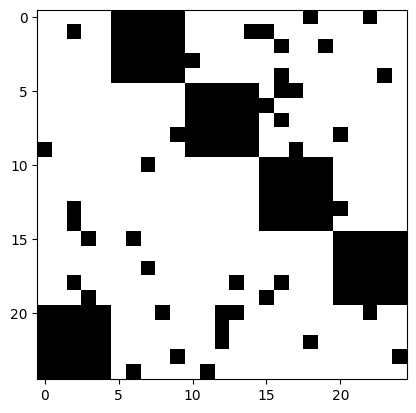

In [6]:
plt.imshow(A, cmap="gray_r")   
#plt.colorbar()               
plt.show()

In [7]:
G = nx.from_numpy_array(A, create_using=nx.DiGraph)

In [8]:
def clustered_circular_pos(n, m, big_radius=5, small_radius=0.8):
    pos = {}

    # cluster centers on a large circle
    cluster_angles = np.linspace(0, 2*np.pi, n, endpoint=False)

    for c, theta in enumerate(cluster_angles):
        center_x = big_radius * np.cos(theta)
        center_y = big_radius * np.sin(theta)
        center = np.array([center_x, center_y])

        # nodes within this cluster on a small circle
        node_angles = np.linspace(0, 2*np.pi, m, endpoint=False)
        for j, phi in enumerate(node_angles):
            node = c * m + j
            x = center_x + small_radius * np.cos(phi)
            y = center_y + small_radius * np.sin(phi)
            pos[node] = (x, y)

    return pos

In [9]:
def edge_colours_by_cluster(G, n, m):
    colors = []

    for u, v in G.edges():
        cu = u // m
        cv = v // m

        # check if it's between consecutive clusters
        if (cv == (cu + 1) % n):   # use % n if clusters wrap in a circle
            colors.append("tab:cyan")
        elif (cv == (cu) % n):
            colors.append("orange")
        else:
            colors.append("red")

    return colors

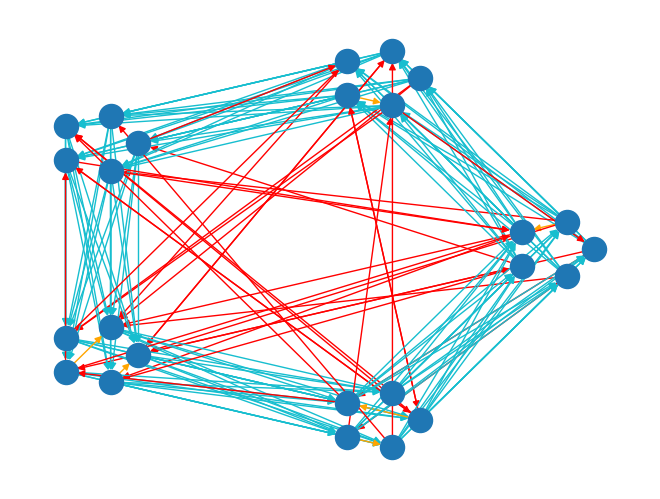

In [10]:
pos = clustered_circular_pos(clusters, clust_size)
edge_colours = edge_colours_by_cluster(G, clusters, clust_size)
#nx.draw(G, pos, with_labels=True, node_size=300)
nx.draw(G, pos, node_size=300, node_color="tab:blue", edge_color=edge_colours)

We define cluster size as $m$ and number of clusters as $n$.
We note that the ratio of "in-edges" (edges from the ith community to the (i+1)th community) to the "out-edges" (edges otherwise) is not exactly the ratio $\frac{p_{out}}{p_{in}}$, because our SBM attempts to draw $m$ "in-edges" and $(n-1)m$ "out-edges". <br>
The expected number of "in-edges" is given by $p_{in}m$ and "out-edges" by $p_{out}(n-1)m$. <br>
Therefore, we define the out/in-edge ratio as $E_{out/in} = \frac{p_{out}}{p_{in}}(n-1)$. <br>
As this ratio approaches 1, the noise makes our planted communities otherwise indistinguishable from the rest of the graph. Our goal is here is to find the threshold $E_{out/in}$ where our spectral gap $\lambda_2 - \lambda_1$ fails to find the number of planted communities.

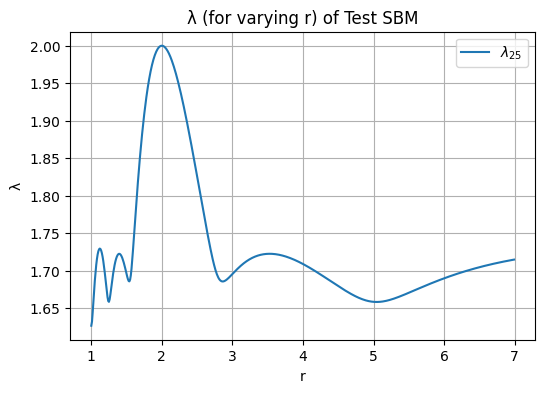

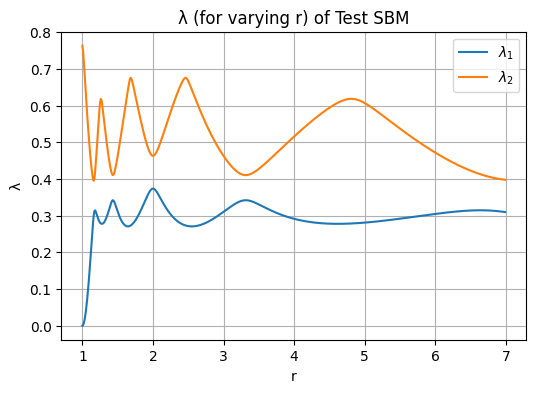

In [11]:
n = clusters * clust_size
theta = 2*np.pi
eigInterest = [n]
rValues = [n / 100 for n in range(100, 700)]
eigVsel_rplot(G, "Test SBM", rValues, eigInterest)
eigInterest = [1, 2]
eigVsel_rplot(G, "Test SBM", rValues, eigInterest)

In [12]:
clusters = 5
clust_size = 2
p_in = 1
p_out = 0.8
A = sbmCycleGen(clusters, clust_size, p_in, p_out)
print(A)
n = clusters * clust_size
theta = 2*np.pi
eigInterest = [n]

[[0 0 1 1 1 1 1 1 1 1]
 [1 0 1 1 1 1 1 1 1 1]
 [0 1 0 1 1 1 1 0 1 1]
 [0 1 1 0 1 1 0 1 1 1]
 [1 1 0 1 0 1 1 1 1 0]
 [0 1 1 1 1 0 1 1 0 1]
 [0 1 1 1 1 1 0 1 1 1]
 [1 1 1 1 1 1 1 0 1 1]
 [1 1 0 1 1 1 1 0 0 1]
 [1 1 1 1 1 1 0 0 1 0]]


#### We now write a function that generates realisations of our SBM and finds the optimal choice for $r$ based on the spectral gap $\lambda_2 - \lambda_1$. <br>
We create the figures below by generating 1000 realisations of our SBM, with cluster size $m = 10$ and varying numbers of planted clusters $n \in {3, 4, 5}.$ We then calculate the eigenvalues of the normalised magnetic Laplacian of our cyclic SBM graphs, and select the $r$ where the spectral gap is maximised. <br>
After running our trials, we sum the number of successful trials and divide by the total to derive $\hat{p}$ as the proportion of trials where the spectral gap successfully found the number of planted clusters. The figures below plot $\hat{p}$ against $p_{out}$ and $E_{out/in}$ as quantifiers of the amount of "noise" in our network.

In [13]:
def sbmClusterTest_p_out(clusters, clust_size, p_inValues, p_outValues, sims, rValues):
    #rValues = [2, 3, 4, 5, 6] #determines the number of clusters we test for, add more if needed
    rValLength = len(rValues)
    full_results = {}
    results = {}
    for p_in in p_inValues:
        full_results[p_in] = {}
        results[p_in] = []
        for p_out in p_outValues:
            full_results[p_in][p_out] = np.zeros(sims) 

    for p_in in p_inValues:
        for p_out in p_outValues:
            for i in range(0, sims):
                A = sbmCycleGen(clusters, clust_size, p_in, p_out)
                G = nx.from_numpy_array(A, create_using=nx.DiGraph)
                A = nx.adjacency_matrix(G)
                eigArray = eig_rValuesN(A, rValues)
                spectralGap = np.zeros(rValLength)
                for k in range(0, rValLength):
                    spectralGap[k] = eigArray[k, 2] - eigArray[k, 1]
                rChoice = rValues[np.argmax(spectralGap)]
                if rChoice == clusters:
                    full_results[p_in][p_out][i] = 1
            results[p_in].append(np.mean(full_results[p_in][p_out]))

    return results, full_results

In [14]:
clusters = 3
clust_size = 10
p_inValues = [1, 0.8, 0.6]
p_outSpecial = [i / 200 for i in range(0, 80)]
p_outValues = p_outSpecial + [0.5, 0.6, 0.7, 0.8, 0.9, 1]
sims = 1000
rValues = [3, 4, 5, 6] #[2, 3, 4, 5, 6]
results, full_results = sbmClusterTest_p_out(clusters, clust_size, p_inValues, p_outValues, sims, rValues)

In [15]:
print(results)

{1: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.998, 0.997, 0.996, 0.996, 0.985, 0.988, 0.958, 0.929, 0.92, 0.864, 0.777, 0.745, 0.68, 0.598, 0.5, 0.437, 0.331, 0.248, 0.204, 0.158, 0.113, 0.085, 0.049, 0.023, 0.025, 0.018, 0.006, 0.002, 0.005, 0.001, 0.002, 0.002, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.8: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.999, 1.0, 0.999, 0.994, 0.984, 0.979, 0.97, 0.925, 0.902, 0.843, 0.788, 0.709, 0.651, 0.531, 0.47, 0.381, 0.307, 0.211, 0.187, 0.117, 0.086, 0.077, 0.061, 0.024, 0.017, 0.011, 0.002, 0.005, 0.003, 0.003, 0.0, 0.002, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.6: [1.0

In [16]:
threshInterest = [0.999, 0.99, 0.95, 0.9, 0.85]
thresholds = {}
for r in p_inValues:
    thresholds[r] = []
    for thr in threshInterest:
        p_outIndex = np.argmax(np.array(results[r])<thr)-1
        E_outValue = p_outValues[p_outIndex] * ((clusters-1)/r)
        thresholds[r].append(E_outValue)

In [17]:
print(thresholds)

{1: [0.24, 0.28, 0.31, 0.33, 0.34], 0.8: [0.275, 0.28750000000000003, 0.325, 0.35000000000000003, 0.35000000000000003], 0.6: [0.26666666666666666, 0.2833333333333334, 0.33333333333333337, 0.35, 0.3666666666666667]}


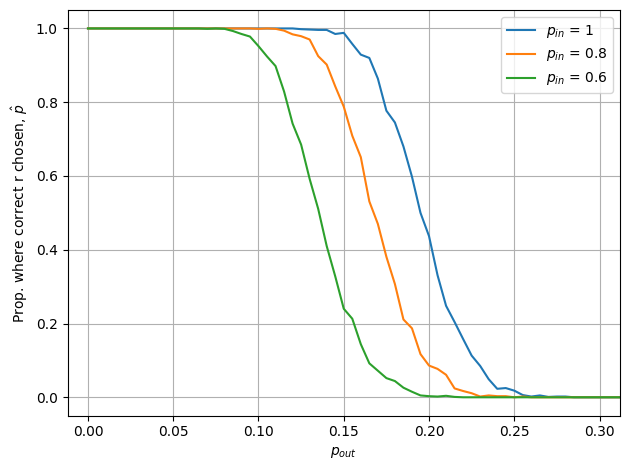

In [18]:
for p_in in p_inValues:
    plt.plot(p_outValues, results[p_in], label =f"$p_{{in}}$ = {p_in}")
plt.legend()
plt.xlabel("$p_{out}$")
plt.ylabel(r"Prop. where correct r chosen, $\hat{p}$")
#plt.title(f"Proportion of realisations where correct r chosen for given $p_in, p_out$, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.xlim(-0.012, 0.312)
plt.show()

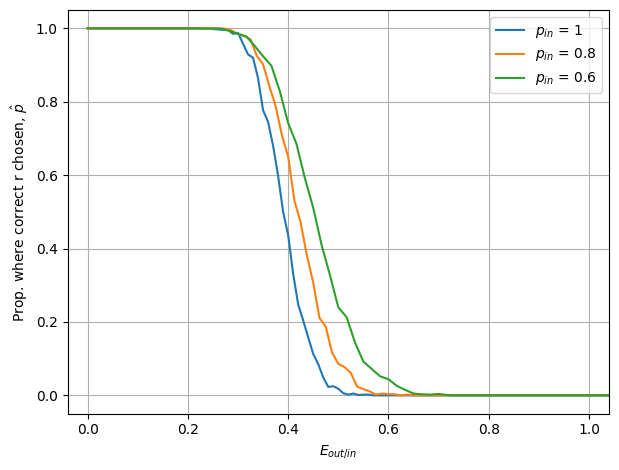

In [19]:
for p_in in p_inValues:
    plt.plot(np.array(p_outValues)*((clusters-1)/p_in), results[p_in], label =f"$p_{{in}}$ = {p_in}")
plt.legend()
plt.xlabel("$E_{out/in}$")
plt.ylabel(r"Prop. where correct r chosen, $\hat{p}$")
#plt.title(f"Proportion of realisations where correct r chosen for given $p_in, E_out/in$, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.xlim(-0.04, 1.04)
plt.show()

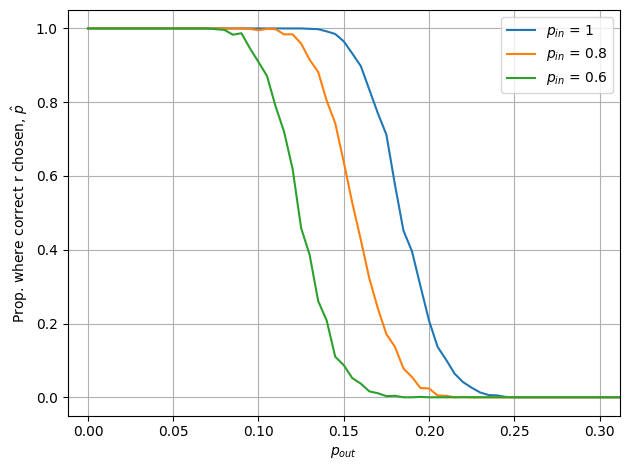

In [20]:
clusters = 4
clust_size = 10
p_inValues = [1, 0.8, 0.6]
p_outSpecial = [i / 200 for i in range(0, 80)]
p_outValues = p_outSpecial + [0.5, 0.6, 0.7, 0.8, 0.9, 1]
sims = 1000
rValues = [3, 4, 5, 6] #[2, 3, 4, 5, 6]
results, full_results = sbmClusterTest_p_out(clusters, clust_size, p_inValues, p_outValues, sims, rValues)

for p_in in p_inValues:
    plt.plot(p_outValues, results[p_in], label =f"$p_{{in}}$ = {p_in}")
plt.legend()
plt.xlabel("$p_{out}$")
plt.ylabel(r"Prop. where correct r chosen, $\hat{p}$")
#plt.title(f"Proportion of realisations where correct r chosen for given $p_in, p_out$, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.xlim(-0.012, 0.312)
plt.show()

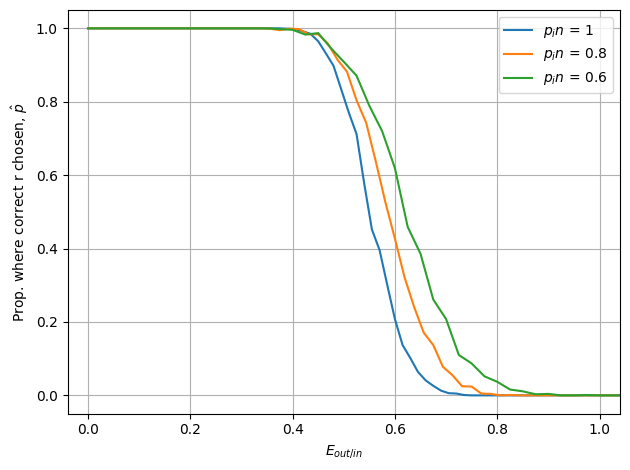

In [21]:
for p_in in p_inValues:
    plt.plot(np.array(p_outValues)*((clusters-1)/p_in), results[p_in], label =f"$p_in$ = {p_in}")
plt.legend()
plt.xlabel("$E_{out/in}$")
plt.ylabel(r"Prop. where correct r chosen, $\hat{p}$")
#plt.title(f"Proportion of realisations where correct r chosen for given $p_in, E_out/in$, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.xlim(-0.04, 1.04)
plt.show()

In [22]:
threshInterest = [0.999, 0.99, 0.95, 0.9, 0.85]
thresholds = {}
for r in p_inValues:
    thresholds[r] = []
    for thr in threshInterest:
        p_outIndex = np.argmax(np.array(results[r])<thr)-1
        E_outValue = p_outValues[p_outIndex] * ((clusters-1)/r)
        thresholds[r].append(E_outValue)

In [23]:
print(thresholds)

{1: [0.39, 0.42000000000000004, 0.44999999999999996, 0.46499999999999997, 0.48], 0.8: [0.35625, 0.4125, 0.46875, 0.48750000000000004, 0.5062500000000001], 0.6: [0.35000000000000003, 0.4, 0.44999999999999996, 0.5, 0.525]}


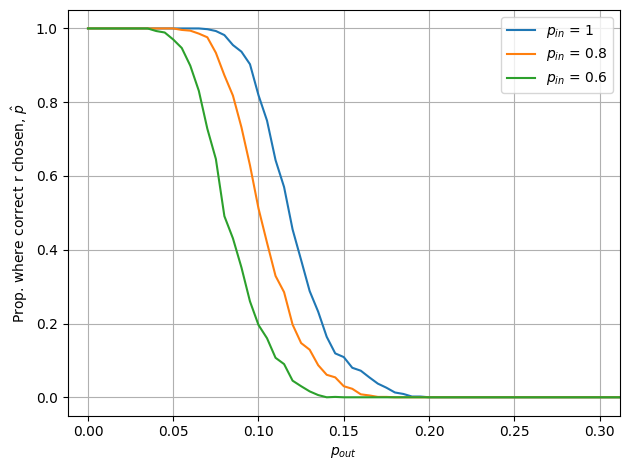

In [25]:
clusters = 5
clust_size = 10
p_inValues = [1, 0.8, 0.6]
p_outSpecial = [i / 200 for i in range(0, 80)]
p_outValues = p_outSpecial + [0.5, 0.6, 0.7, 0.8, 0.9, 1]
sims = 1000
rValues = [3, 4, 5, 6] #[2, 3, 4, 5, 6]
results, full_results = sbmClusterTest_p_out(clusters, clust_size, p_inValues, p_outValues, sims, rValues)

for p_in in p_inValues:
    plt.plot(p_outValues, results[p_in], label =f"$p_{{in}}$ = {p_in}")
plt.legend()
plt.xlabel("$p_{out}$")
plt.ylabel(r"Prop. where correct r chosen, $\hat{p}$")
#plt.title(f"Proportion of realisations where correct r chosen for given $p_in, p_out$, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.xlim(-0.012, 0.312)
plt.show()

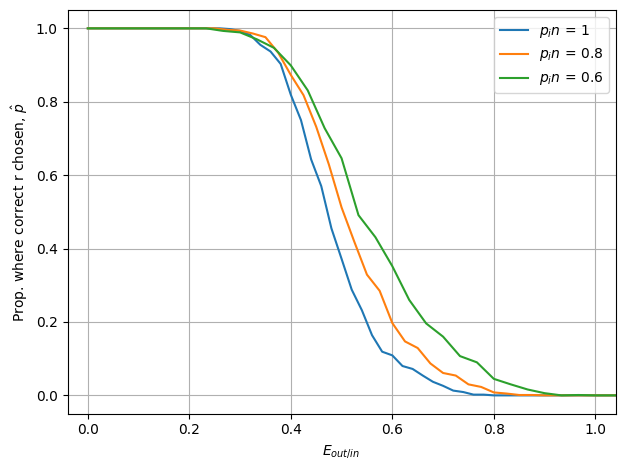

In [26]:
for p_in in p_inValues:
    plt.plot(np.array(p_outValues)*((clusters-1)/p_in), results[p_in], label =f"$p_in$ = {p_in}")
plt.legend()
plt.xlabel("$E_{out/in}$")
plt.ylabel(r"Prop. where correct r chosen, $\hat{p}$")
#plt.title(f"Proportion of realisations where correct r chosen for given $p_in, E_out/in$, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.xlim(-0.04, 1.04)
plt.show()

In [27]:
threshInterest = [0.999, 0.99, 0.95, 0.9, 0.85]
thresholds = {}
for r in p_inValues:
    thresholds[r] = []
    for thr in threshInterest:
        p_outIndex = np.argmax(np.array(results[r])<thr)-1
        E_outValue = p_outValues[p_outIndex] * ((clusters-1)/r)
        thresholds[r].append(E_outValue)

In [28]:
print(thresholds)

{1: [0.26, 0.3, 0.34, 0.38, 0.38], 0.8: [0.25, 0.3, 0.35000000000000003, 0.375, 0.4], 0.6: [0.23333333333333336, 0.26666666666666666, 0.33333333333333337, 0.3666666666666667, 0.4]}
